# 01 — EDA & Data Understanding
## Home Credit Default Risk

Triển khai **Bước 1** (hiểu cấu trúc tổng thể) và **Bước 2** (EDA bảng chính `application_train`) theo `docs/eda-to-feature-engineering-guide.md`.

Mỗi block EDA kết thúc bằng một câu hỏi → quyết định feature engineering.

## Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
sns.set_theme(style='whitegrid')

GREEN, RED = '#5DCAA5', '#D85A30'

# Notebook chạy từ notebooks/ → data nằm ở ../data/raw
DATA_DIR = Path('..') / 'data' / 'raw'
if not DATA_DIR.exists():
    DATA_DIR = Path('data') / 'raw'  # fallback nếu chạy từ project root
assert DATA_DIR.exists(), f'Khong tim thay data dir: {DATA_DIR.resolve()}'
print('DATA_DIR =', DATA_DIR.resolve())

DATA_DIR = D:\Explainable-Homecredit-Approval-System\data\raw


---
## Bước 1 — Hiểu cấu trúc tổng thể

Trước khi nhìn feature nào, hiểu quan hệ giữa các bảng và kích thước của chúng.

### 1.1 — Kích thước mỗi bảng

In [2]:
files = {
    'application_train': 'application_train.csv',
    'bureau':            'bureau.csv',
    'bureau_balance':    'bureau_balance.csv',
    'previous_app':      'previous_application.csv',
    'pos_cash':          'POS_CASH_balance.csv',
    'installments':      'installments_payments.csv',
    'credit_card':       'credit_card_balance.csv',
}

shapes = {}
for name, fname in files.items():
    # usecols=[0] đọc 1 cột để đếm rows nhanh, không nạp cả bảng lớn vào RAM
    n_rows = len(pd.read_csv(DATA_DIR / fname, usecols=[0]))
    n_cols = pd.read_csv(DATA_DIR / fname, nrows=0).shape[1]
    shapes[name] = (n_rows, n_cols)
    print(f'{name:20s}: {n_rows:>10,} rows x {n_cols:>3} cols')

application_train   :    307,511 rows x 122 cols
bureau              :  1,716,428 rows x  17 cols
bureau_balance      : 27,299,925 rows x   3 cols
previous_app        :  1,670,214 rows x  37 cols
pos_cash            : 10,001,358 rows x   8 cols
installments        : 13,605,401 rows x   8 cols
credit_card         :  3,840,312 rows x  23 cols


### 1.2 — Coverage & số records / khách hàng

In [3]:
app = pd.read_csv(DATA_DIR / 'application_train.csv')
n_customers = app['SK_ID_CURR'].nunique()  # ~307k
print(f'Tong so khach hang (application_train): {n_customers:,}\n')

# bureau_balance chi co SK_ID_BUREAU (khong co SK_ID_CURR) -> map qua bureau
bureau_map = pd.read_csv(DATA_DIR / 'bureau.csv', usecols=['SK_ID_CURR', 'SK_ID_BUREAU'])

rows = []
for name, fname in files.items():
    if name == 'application_train':
        continue
    cols = pd.read_csv(DATA_DIR / fname, nrows=0).columns
    if 'SK_ID_CURR' in cols:
        ids = pd.read_csv(DATA_DIR / fname, usecols=['SK_ID_CURR'])
        cur = ids['SK_ID_CURR']
    else:
        # bureau_balance: SK_ID_BUREAU -> SK_ID_CURR qua bureau
        ids = pd.read_csv(DATA_DIR / fname, usecols=['SK_ID_BUREAU'])
        cur = ids.merge(bureau_map, on='SK_ID_BUREAU', how='left')['SK_ID_CURR']
    n_unique = cur.nunique()
    rows.append({
        'table': name,
        'coverage_pct': n_unique / n_customers * 100,
        'avg_rows_per_customer': len(ids) / n_unique if n_unique else 0,
    })

coverage_df = pd.DataFrame(rows).sort_values('coverage_pct')
coverage_df

Tong so khach hang (application_train): 307,511



,table,coverage_pct,avg_rows_per_customer
5,credit_card,33.6762,37.0837
1,bureau_balance,43.7519,202.9101
0,bureau,99.4472,5.6127
3,pos_cash,109.6715,29.6554
2,previous_app,110.1935,4.9290
4,installments,110.4308,40.0646


**Câu hỏi**: Bảng nào coverage thấp (< 70%)?
→ Khách hàng không có records ở bảng đó sẽ nhận `NaN` sau join — cần strategy riêng (fill 0 cho count features, hoặc flag `has_<table>`).

In [4]:
low_cov = coverage_df[coverage_df['coverage_pct'] < 70]
print('Bang coverage < 70%:')
print(low_cov[['table', 'coverage_pct']].to_string(index=False) if len(low_cov) else '  (khong co)')

Bang coverage < 70%:
         table  coverage_pct
   credit_card       33.6762
bureau_balance       43.7519


---
## Bước 2 — EDA bảng chính (`application_train`)

### 2.1 — Phân tích TARGET

TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

Imbalance ratio (0:1) = 11.4 : 1


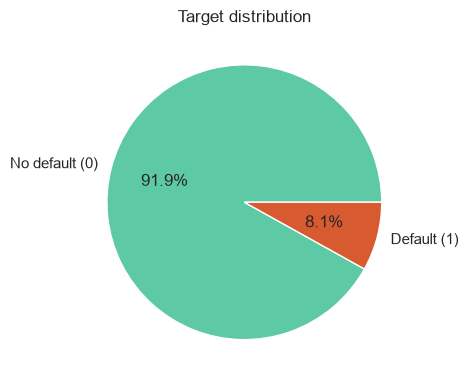

In [5]:
target_dist = app['TARGET'].value_counts(normalize=True)
print(target_dist)  # ~91.9% class 0, ~8.1% class 1

imbalance_ratio = target_dist[0] / target_dist[1]
print(f'\nImbalance ratio (0:1) = {imbalance_ratio:.1f} : 1')

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(app['TARGET'].value_counts(),
       labels=['No default (0)', 'Default (1)'],
       autopct='%1.1f%%', colors=[GREEN, RED])
ax.set_title('Target distribution')
plt.tight_layout()
plt.show()

**Câu hỏi**: Tỷ lệ imbalance bao nhiêu?
→ Quyết định: `class_weight='balanced'` hoặc SMOTE; metric dùng **ROC-AUC / PR-AUC** thay vì Accuracy.

### 2.2 — Missing value analysis

In [6]:
def missing_summary(df, name=''):
    miss = df.isnull().sum()
    miss_pct = miss / len(df) * 100
    result = pd.DataFrame({
        'missing_count': miss,
        'missing_pct': miss_pct,
        'dtype': df.dtypes,
    }).query('missing_count > 0').sort_values('missing_pct', ascending=False)
    print(f'=== {name} — {len(result)} cols co missing ===')
    return result

app_miss = missing_summary(app, 'application_train')
app_miss.head(20)

=== application_train — 67 cols co missing ===


,missing_count,missing_pct,dtype
COMMONAREA_MEDI,214865,69.8723,float64
COMMONAREA_MODE,214865,69.8723,float64
COMMONAREA_AVG,214865,69.8723,float64
NONLIVINGAPARTMENTS_MODE,213514,69.4330,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.4330,float64
NONLIVINGAPARTMENTS_AVG,213514,69.4330,float64
FONDKAPREMONT_MODE,210295,68.3862,object
LIVINGAPARTMENTS_AVG,210199,68.3550,float64
LIVINGAPARTMENTS_MEDI,210199,68.3550,float64
LIVINGAPARTMENTS_MODE,210199,68.3550,float64


In [7]:
# Phan loai missing theo muc do
high_miss = app_miss[app_miss['missing_pct'] > 40]
mid_miss  = app_miss[(app_miss['missing_pct'] > 10) & (app_miss['missing_pct'] <= 40)]
low_miss  = app_miss[app_miss['missing_pct'] <= 10]

print(f'High missing (>40%) : {len(high_miss)} cols -> drop hoac chi giu binary flag')
print(f'Mid  missing (10-40%): {len(mid_miss)} cols -> impute co chien luoc')
print(f'Low  missing (<10%) : {len(low_miss)} cols -> impute don gian')

High missing (>40%) : 49 cols -> drop hoac chi giu binary flag
Mid  missing (10-40%): 8 cols -> impute co chien luoc
Low  missing (<10%) : 10 cols -> impute don gian


In [8]:
# Cac feature quan trong co missing nhieu khong?
key_feats = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
             'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE']
app_miss.reindex(key_feats).dropna(how='all')

,missing_count,missing_pct,dtype
EXT_SOURCE_1,173378,56.3811,float64
EXT_SOURCE_2,660,0.2146,float64
EXT_SOURCE_3,60965,19.8253,float64
AMT_ANNUITY,12,0.0039,float64
AMT_GOODS_PRICE,278,0.0904,float64
OWN_CAR_AGE,202929,65.9908,float64


**Câu hỏi**: EXT_SOURCE_1/2/3, AMT_* có missing nhiều không?
→ EXT_SOURCE_1 thường missing ~56% → tạo flag `EXT_SOURCE_1_MISSING` song song impute median.

### 2.3 — Phân tích features số theo TARGET

Tìm features có **phân phối khác biệt rõ** giữa class 0 và class 1.

In [9]:
numeric_cols = app.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['SK_ID_CURR', 'TARGET']]

# Mean tung feature theo TARGET
by_target = app[numeric_cols + ['TARGET']].groupby('TARGET').mean().T
by_target['diff_abs'] = (by_target[1] - by_target[0]).abs()
by_target['ratio_1_vs_0'] = by_target[1] / by_target[0]
by_target = by_target.sort_values('diff_abs', ascending=False)

print('Top 20 features khac biet nhat giua 2 class (theo |mean diff|):')
by_target.head(20)

Top 20 features khac biet nhat giua 2 class (theo |mean diff|):


TARGET,0,1,diff_abs,ratio_1_vs_0
AMT_GOODS_PRICE,"542,736.7950","488,972.4126","53,764.3824",0.9009
AMT_CREDIT,"602,648.2820","557,778.5277","44,869.7543",0.9255
DAYS_EMPLOYED,"65,696.1461","42,394.6754","23,301.4707",0.6453
AMT_INCOME_TOTAL,"169,077.7223","165,611.7609","3,465.9614",0.9795
DAYS_BIRTH,"-16,138.1764","-14,884.8281","1,253.3483",0.9223
AMT_ANNUITY,"27,163.6233","26,481.7443",681.8791,0.9749
DAYS_REGISTRATION,"-5,029.9411","-4,487.1270",542.8141,0.8921
DAYS_ID_PUBLISH,"-3,017.2198","-2,732.0996",285.1202,0.9055
DAYS_LAST_PHONE_CHANGE,-976.3883,-808.7968,167.5915,0.8284
OWN_CAR_AGE,11.9355,13.6687,1.7332,1.1452


In [10]:
# Pearson corr cua tung numeric feature voi TARGET (bat linear signal)
target_corr = app[numeric_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
target_corr_sorted = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
print('Top 15 |corr| voi TARGET:')
print(target_corr_sorted.head(15))

Top 15 |corr| voi TARGET:
EXT_SOURCE_3                  -0.1789
EXT_SOURCE_2                  -0.1605
EXT_SOURCE_1                  -0.1553
DAYS_BIRTH                     0.0782
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                 -0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                 -0.0440
FLOORSMAX_MEDI                -0.0438
Name: TARGET, dtype: float64


**Visualize** phân phối top features theo class:

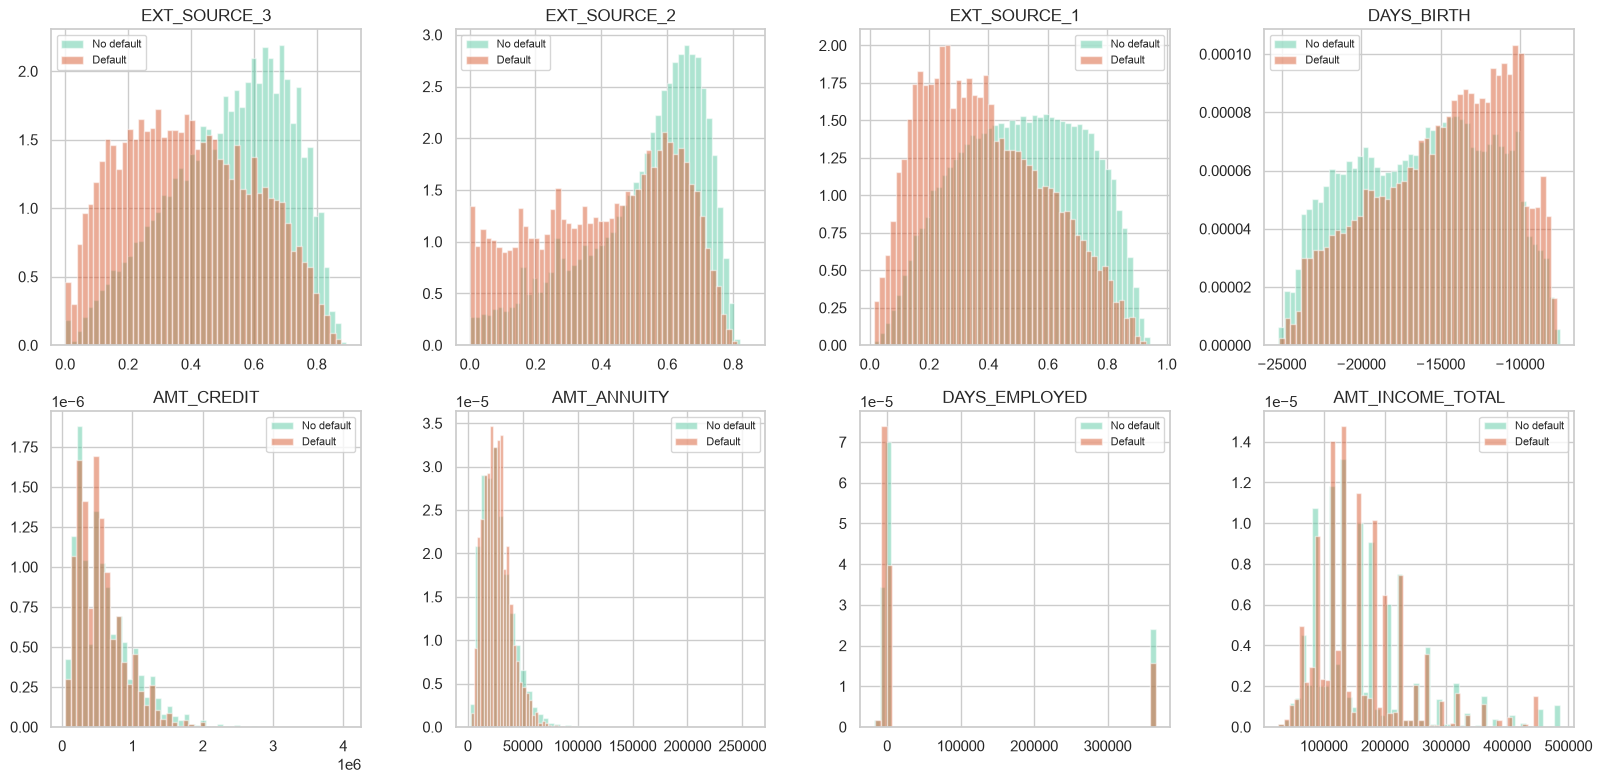

In [11]:
top_features = ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1',
                'DAYS_BIRTH', 'AMT_CREDIT', 'AMT_ANNUITY',
                'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), top_features):
    for tval, color, label in [(0, GREEN, 'No default'), (1, RED, 'Default')]:
        data = app.loc[app['TARGET'] == tval, col].dropna()
        # clip AMT_INCOME_TOTAL de chong outlier keo dan histogram
        if col == 'AMT_INCOME_TOTAL':
            data = data.clip(upper=data.quantile(0.99))
        ax.hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Câu hỏi**: Feature nào histogram 2 class tách biệt rõ?
→ Ưu tiên engineer (bins, ratios) từ chúng. EXT_SOURCE_* thường tách rõ nhất.

### 2.3b — Correlation heatmap (top features vs TARGET)

Trả lời 2 câu hỏi cùng lúc: feature nào corr với TARGET, và feature nào corr **với nhau** (→ candidates drop ở Bước 6.2). Giới hạn top 20 — heatmap 120+ cols không đọc được.

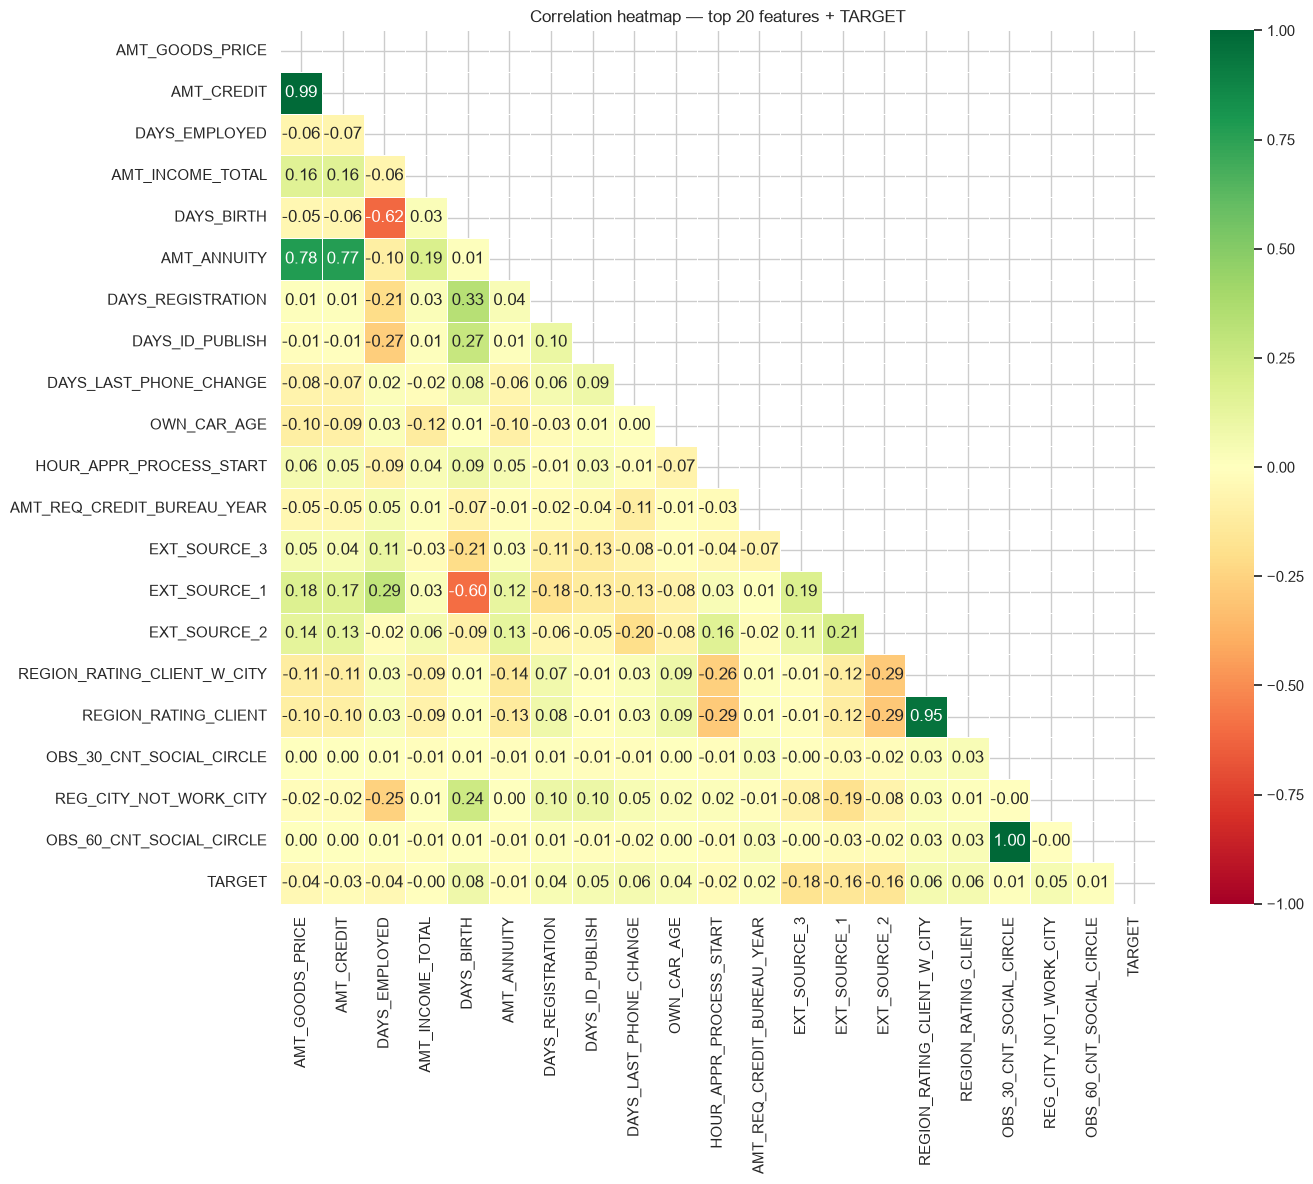

In [12]:
top20 = by_target.head(20).index.tolist()
corr_data = app[top20 + ['TARGET']].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_data, dtype=bool))  # chi show lower triangle
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation heatmap — top 20 features + TARGET')
plt.tight_layout()
plt.show()

In [13]:
# Liet ke cap feature redundant (|corr| > 0.85) de ghi nho cho Buoc 6.2
cm = corr_data.drop(index='TARGET', columns='TARGET').abs()
upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
pairs = (upper.stack()
              .loc[lambda s: s > 0.85]
              .sort_values(ascending=False))
print('Cap feature |corr| > 0.85 (candidates drop):')
print(pairs.to_string() if len(pairs) else '  (khong co trong top 20)')

Cap feature |corr| > 0.85 (candidates drop):
OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE   0.9985
AMT_GOODS_PRICE              AMT_CREDIT                 0.9870
REGION_RATING_CLIENT_W_CITY  REGION_RATING_CLIENT       0.9508


**Lưu ý**: Pearson chỉ bắt **linear**. Tree models (XGBoost/LightGBM) bắt non-linear → heatmap KHÔNG thay thế feature importance (Bước 6.3). Dùng song song: heatmap tìm redundancy, importance tìm predictive power.

### 2.4 — Phân tích features categorical

In [14]:
cat_cols = app.select_dtypes(include=['object']).columns.tolist()
print(f'{len(cat_cols)} categorical cols:\n', cat_cols)

16 categorical cols:
 ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


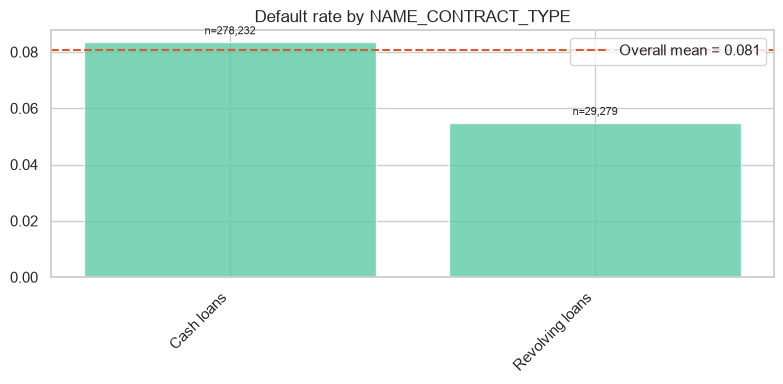

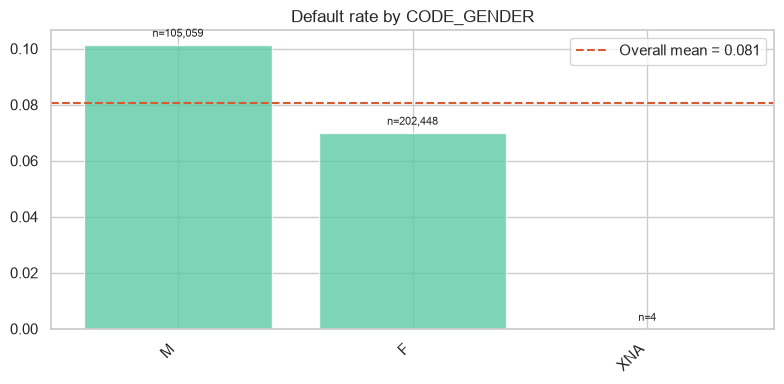

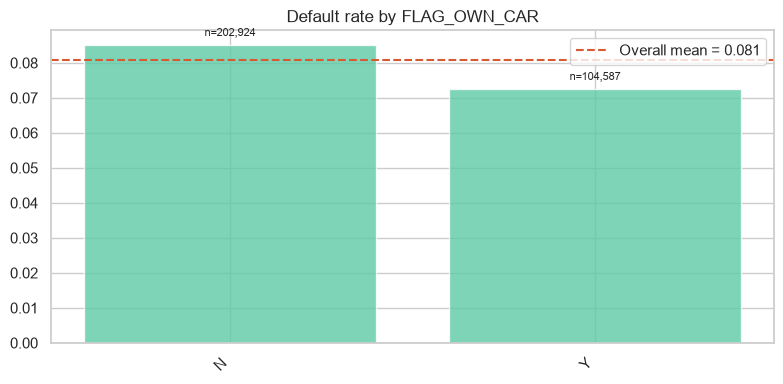

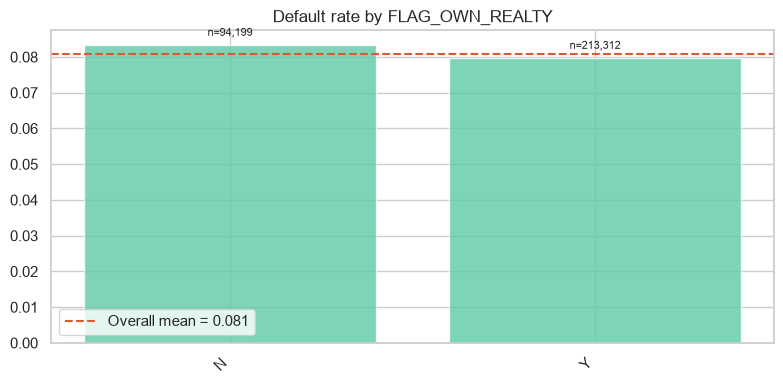

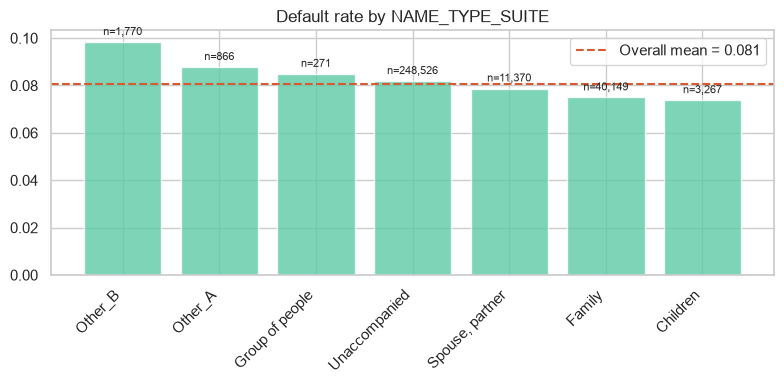

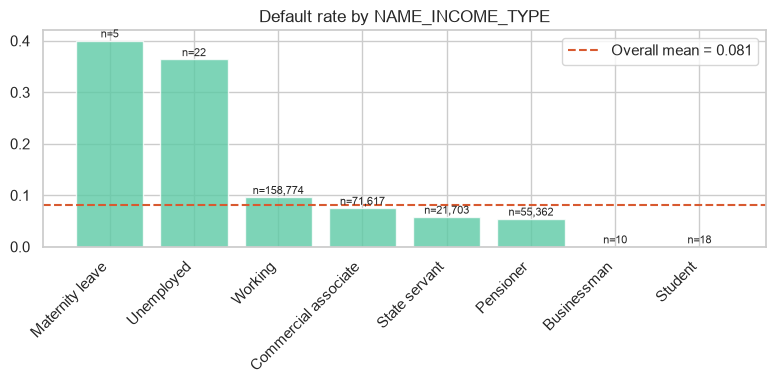

In [15]:
overall = app['TARGET'].mean()
for col in cat_cols[:6]:  # top 6 de plot
    rates = app.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    counts = app[col].value_counts()

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(rates.index.astype(str), rates.values, color=GREEN, alpha=0.8)
    ax.axhline(overall, color=RED, linestyle='--', label=f'Overall mean = {overall:.3f}')
    for bar, cat in zip(bars, rates.index):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'n={counts[cat]:,}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Default rate by {col}')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Câu hỏi**: Category nào default rate cao bất thường?
→ Encoding: target encoding cho high-cardinality, one-hot cho ít levels.

### 2.5 — Phát hiện anomalies

In [16]:
# DAYS_EMPLOYED: 365243 la placeholder cho retired/unemployed
print('DAYS_EMPLOYED top values:')
print(app['DAYS_EMPLOYED'].value_counts().head())
n_anom = (app['DAYS_EMPLOYED'] == 365243).sum()
print(f'\nRows DAYS_EMPLOYED == 365243: {n_anom:,} ({n_anom/len(app)*100:.1f}%)')

DAYS_EMPLOYED top values:
DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
Name: count, dtype: int64

Rows DAYS_EMPLOYED == 365243: 55,374 (18.0%)


In [17]:
# Xu ly anomaly + derive tuoi (chi trong notebook EDA; logic that nam o src/data/features.py)
app['DAYS_EMPLOYED_ANOMALY'] = (app['DAYS_EMPLOYED'] == 365243).astype(int)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)
app['AGE_YEARS'] = (app['DAYS_BIRTH'].abs() / 365)
print('AGE_YEARS describe:')
print(app['AGE_YEARS'].describe())

AGE_YEARS describe:
count   307,511.0000
mean         43.9370
std          11.9561
min          20.5178
25%          34.0082
50%          43.1507
75%          53.9233
max          69.1205
Name: AGE_YEARS, dtype: float64


In [18]:
# Outlier check bang IQR (k=3 -> extreme outliers)
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
    q1, q3 = app[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((app[col] < q1 - 3*iqr) | (app[col] > q3 + 3*iqr)).sum()
    print(f'{col:18s}: {n_out:>6,} extreme outliers (>3*IQR)')

AMT_INCOME_TOTAL  :  3,014 extreme outliers (>3*IQR)
AMT_CREDIT        :    444 extreme outliers (>3*IQR)
AMT_ANNUITY       :  1,024 extreme outliers (>3*IQR)


---
## Tóm tắt Bước 1 + 2 → quyết định

| Quan sát EDA | Quyết định |
|---|---|
| TARGET imbalance ~8% | `class_weight='balanced'` / SMOTE; metric ROC-AUC + PR-AUC |
| EXT_SOURCE_1 missing ~56% | flag `EXT_SOURCE_1_MISSING` + impute median |
| EXT_SOURCE_* tách rõ 2 class | engineer mean/std/product (Bước 5.1) |
| DAYS_EMPLOYED == 365243 | → NaN + flag `DAYS_EMPLOYED_ANOMALY` |
| Cặp feature corr > 0.85 | drop redundant ở Bước 6.2 |
| Bảng coverage < 70% | fill 0 + flag `has_<table>` sau join |

**Tiếp theo**: Bước 3 — EDA từng bảng phụ (`02_feature_engineering.ipynb`).